In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [5]:
X = df.iloc[:,0].values
Y = df.iloc[:,1].values

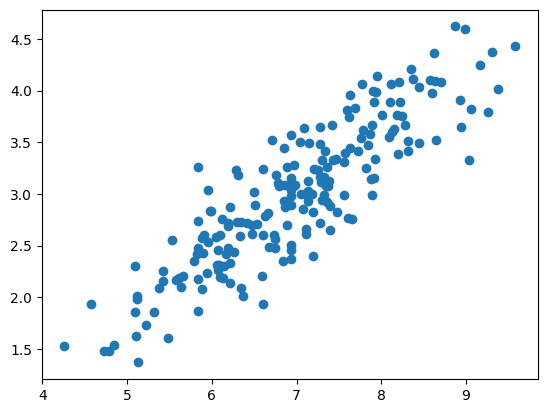

In [6]:
plt.scatter(X,Y)

In [7]:
# Linear Regression

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()

In [13]:
lr.fit(X_train.reshape(-1,1),Y_train)

LinearRegression()

In [14]:
print(lr.coef_,lr.intercept_)

[0.55795197] -0.8961119222429144


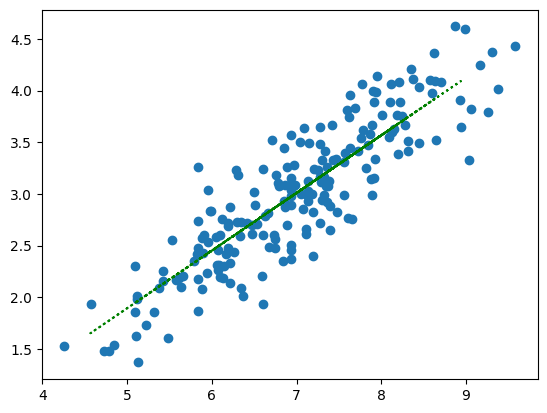

In [15]:
plt.scatter(X,Y)
plt.plot(X_test,lr.predict(X_test.reshape(-1,1)),ls='dotted',color='green')

In [16]:
#Gradient Descent Class

In [48]:
class MyRegressior:

    #Constructor
    def __init__(self,epoch,lr_rate):
        self.m = 1
        self.b = -1
        self.lr = lr_rate
        self.epoch = epoch
        self.loss_array = []

    #Training
    def train(self,X_train,Y_train):
        for i in range(self.epoch):
            #Loss Function
            loss = np.sum((Y_train - self.m*X_train - self.b)*2)
            self.loss_array.append(loss)
            #Slope Calculation
            slope_m = -2*np.sum(np.dot((Y_train-self.m*X_train-self.b),X_train))
            slope_b = -2*np.sum((Y_train-self.m*X_train-self.b))
            #Weight update
            self.m = self.m - self.lr*slope_m
            self.b = self.b - self.lr*slope_b
        return(self.b,self.m)

    #Loss plot
    def loss_plot(self):
        fig1 = plt.plot(np.linspace(1,self.epoch,self.epoch),self.loss_array)
        return(fig1)

    #Loss Jump
    def loss_jump(self):
        fig1 = plt.scatter(np.linspace(1,self.epoch,self.epoch),self.loss_array,marker='.',color='red')
        return(fig1)

In [49]:
MyR = MyRegressior(50,0.00001)

In [50]:
MyR.train(X_train,Y_train)

(-1.0580682815879765, 0.5806647135402422)

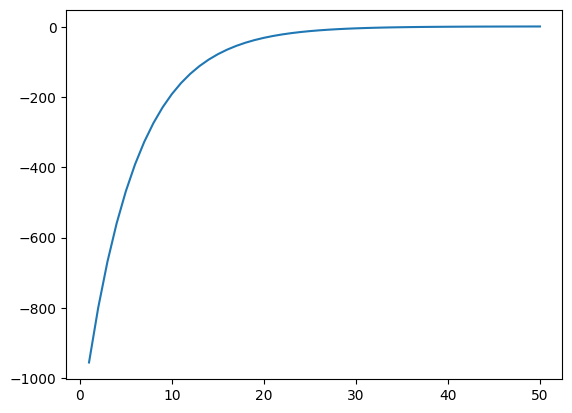

In [51]:
MyR.loss_plot()

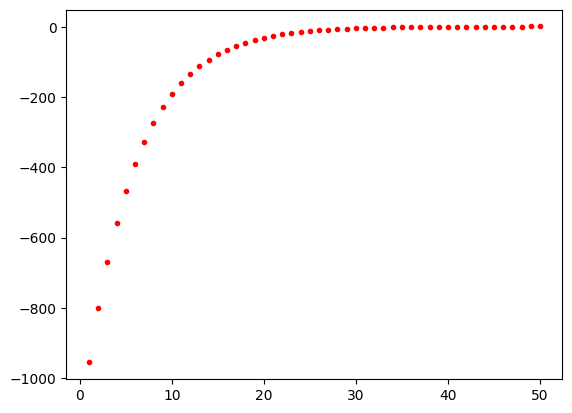

In [52]:
MyR.loss_jump()